In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
from matplotlib.gridspec import GridSpec

## Define colourblind acessible colour palette
colour_palette = ['#FFB000','#648FFF','#785EF0',
                  '#DC267F','#FE6100','#3D1EB2',
                  '#894D80','#16AA02','#B5592B',
                  '#A3C1ED']

# 一.資料載入和合併

In [2]:
excel_file_path3 = 'C:/Users/weisz/OneDrive/Documents/中信兄弟/程式碼/WOBA/woba權重.xlsx'
#C:\Users\weisz\OneDrive\Documents\中信兄弟\程式碼\WOBA
#excel_file_path5 = 'C:/Users/weisz/OneDrive/Documents/中信兄弟/Trackman/new/2022_trackman.xlsx'
excel_file_path6 = 'C:/Users/weisz/OneDrive/Documents/中信兄弟/Season_data/2023_non_trackman.xlsx'
excel_file_path8 = 'C:/Users/weisz/OneDrive/Documents/中信兄弟/Season_data/2024_non_trackman.xlsx'
excel_file_path9 = 'C:/Users/weisz/OneDrive/Documents/中信兄弟/Season_data/2025_non_trackman.xlsx'
excel_file_path10 = 'C:/Users/weisz/OneDrive/Documents/中信兄弟/Season_data/2026_non_trackman.xlsx'
sheet_name = 'Sheet1'

In [3]:
RE = pd.read_excel(excel_file_path3, sheet_name=sheet_name, engine='calamine')
#track_2022 = pd.read_excel(excel_file_path5, sheet_name=sheet_name)
#track_2023_1 = pd.read_excel(excel_file_path6, sheet_name=sheet_name)
track_2023 = pd.read_excel(excel_file_path6, sheet_name=sheet_name, engine='calamine')
track_2024 = pd.read_excel(excel_file_path8, sheet_name=sheet_name, engine='calamine')
track_2025 = pd.read_excel(excel_file_path9, sheet_name=sheet_name, engine='calamine')
track_2026 = pd.read_excel(excel_file_path10, sheet_name=sheet_name, engine='calamine')

In [4]:
col=['date','bName','bHand','bTeamId','Stadium','PlayResult','RunsScored','traj','hardness','ExitSpeed','Angle','Distance','GameID','TaggedHitType','KorBB','BatterId','PitchCall','TaggedPitchType','pType','result','zone25']

In [5]:
#track_2021= track_2021[col]
#track_2022= track_2022[col]
#track_2023_1= track_2023_1[col]
track_2023= track_2023[col]
track_2024=track_2024[col]
track_2025=track_2025[col]
track_2026=track_2026[col]

In [6]:
data = pd.concat([track_2026,track_2025, track_2024, track_2023], ignore_index=True)

#data = data.dropna(subset=['GameID'])

In [7]:
data = data.dropna(subset=['result'])

In [8]:
data

,date,bName,bHand,bTeamId,Stadium,PlayResult,RunsScored,traj,hardness,ExitSpeed,...,Distance,GameID,TaggedHitType,KorBB,BatterId,PitchCall,TaggedPitchType,pType,result,zone25
3,2026-07-16T10:35:00.000Z,張皓崴,L,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,G,M,88.43976,...,24.32827,20260716-TaoyuanStadium-1,GroundBall,Undefined,1.000323e+09,InPlay,Fastball,FF,GO,14
6,2026-07-16T10:35:00.000Z,陳重羽,R,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,F,M,83.98778,...,296.21835,20260716-TaoyuanStadium-1,FlyBall,Undefined,1.000015e+09,InPlay,Slider,SL,FO,13
11,2026-07-16T10:35:00.000Z,陳傑憲,L,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,L,H,98.03620,...,325.21111,20260716-TaoyuanStadium-1,FlyBall,Undefined,1.000029e+09,InPlay,Fastball,FF,FO,8
13,2026-07-16T10:35:00.000Z,林子偉,L,65630eed5559b6d7a6d5d202,TaoyuanStadium,Single,0.0,L,H,96.86951,...,258.15513,20260716-TaoyuanStadium-1,LineDrive,Undefined,6.244070e+05,InPlay,ChangeUp,CH,1B,12
15,2026-07-16T10:35:00.000Z,林立,R,65630eed5559b6d7a6d5d202,TaoyuanStadium,FieldersChoice,0.0,G,S,46.41542,...,4.42215,20260716-TaoyuanStadium-1,GroundBall,Undefined,1.000086e+09,InPlay,Cutter,FC,FC,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358064,2023-10-24T16:00:00.000Z,葉子霆,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CU,HBP,1
358068,2023-10-24T16:00:00.000Z,林岳谷,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FF,SO,8
358070,2023-10-24T16:00:00.000Z,董子恩,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,G,M,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CU,GO,18
358073,2023-10-24T16:00:00.000Z,王念好,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,L,H,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FF,1B,19


# 二.資料預處理

## 1.切出年份

In [9]:
data.loc[:, '時間'] = data['date'].str[:10]
data.loc[:, '日期'] = data['時間'].str.replace('-', '', regex=False)
data.loc[:, 'Year'] = data['日期'].str[:4]

In [10]:
year_items = data['Year'].unique()
year_items

array(['2026', '2025', '2024', '2023'], dtype=object)

In [11]:
name_mapping = {
    '65630ee55559b6d7a6d5d200':'Brothers',
    '65630ee95559b6d7a6d5d201':'Dragons', 
    '65630eed5559b6d7a6d5d202':'Monkeys', 
    '65630ef25559b6d7a6d5d203':'Lions',
    '65630ef65559b6d7a6d5d204':'Guardians',
    '6569a9ddaf62a48d3f94b422':'Hawks',
    }

# 新增一列"球員"，根据"Pitcher"列的值匹配中文名
data ['bTeam'] = data ['bTeamId'].map(name_mapping)
data

,date,bName,bHand,bTeamId,Stadium,PlayResult,RunsScored,traj,hardness,ExitSpeed,...,BatterId,PitchCall,TaggedPitchType,pType,result,zone25,時間,日期,Year,bTeam
3,2026-07-16T10:35:00.000Z,張皓崴,L,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,G,M,88.43976,...,1.000323e+09,InPlay,Fastball,FF,GO,14,2026-07-16,20260716,2026,Lions
6,2026-07-16T10:35:00.000Z,陳重羽,R,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,F,M,83.98778,...,1.000015e+09,InPlay,Slider,SL,FO,13,2026-07-16,20260716,2026,Lions
11,2026-07-16T10:35:00.000Z,陳傑憲,L,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,L,H,98.03620,...,1.000029e+09,InPlay,Fastball,FF,FO,8,2026-07-16,20260716,2026,Lions
13,2026-07-16T10:35:00.000Z,林子偉,L,65630eed5559b6d7a6d5d202,TaoyuanStadium,Single,0.0,L,H,96.86951,...,6.244070e+05,InPlay,ChangeUp,CH,1B,12,2026-07-16,20260716,2026,Monkeys
15,2026-07-16T10:35:00.000Z,林立,R,65630eed5559b6d7a6d5d202,TaoyuanStadium,FieldersChoice,0.0,G,S,46.41542,...,1.000086e+09,InPlay,Cutter,FC,FC,19,2026-07-16,20260716,2026,Monkeys
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358064,2023-10-24T16:00:00.000Z,葉子霆,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,CU,HBP,1,2023-10-24,20231024,2023,Guardians
358068,2023-10-24T16:00:00.000Z,林岳谷,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,FF,SO,8,2023-10-24,20231024,2023,Guardians
358070,2023-10-24T16:00:00.000Z,董子恩,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,G,M,NaN,...,NaN,NaN,NaN,CU,GO,18,2023-10-24,20231024,2023,Guardians
358073,2023-10-24T16:00:00.000Z,王念好,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,L,H,NaN,...,NaN,NaN,NaN,FF,1B,19,2023-10-24,20231024,2023,Guardians


In [12]:
name_mapping2 = {
    'Brothers':'台中', 
    'Guardians':'新莊', 
    'Douliu':'斗六', 
    'FargloryDome':'大巨蛋', 
    'TianMUStadium':'天母',
    'BrothersMinor':'屏東',
    'ChengchingLakeStadium':'澄清湖',
    'TainanInternational':'亞太主',
    'TaoyuanStadium':'桃園'
}
name_mapping3 = {
    'Brothers':'Outdoor', 
    'Guardians':'Outdoor', 
    'Douliu':'Outdoor', 
    'FargloryDome':'Dome', 
    'TianMUStadium':'Outdoor',
    'BrothersMinor':'Outdoor',
    'ChengchingLakeStadium':'Outdoor',
    'TainanInternational':'Outdoor',
    'TaoyuanStadium':'Outdoor'
}

data['球場'] = data['Stadium'].map(name_mapping2)
data['室內外'] = data['Stadium'].map(name_mapping3)

In [13]:
name_mapping = {
    'Fastball':'直球', 
    'ChangeUp':'變速球', 
    'Cutter':'卡特球', 
    'Curveball':'曲球', 
    'Splitter':'指叉球',
    'Slider':'滑球', 
    'Sinker':'伸卡球',
    'KnuckleBall':'彈指曲球', 
    'TwoSeamFastBall':'伸卡球', 
    'FourSeamFastBall':'直球', 
    'OneSeamFastBall':'伸卡球',
    'Changeup':'變速球', 
    'Knuckleball':'彈指曲球'  
}

# 新增一列"球員"，根据"Pitcher"列的值匹配中文名
mask = data['Year'].isin(['2021', '2022'])
data.loc[mask, '球種'] = data.loc[mask, 'TaggedPitchType'].map(name_mapping)

In [14]:
name_mapping = {
    'FF':'直球', 
    'CH':'變速球', 
    'FC':'卡特球', 
    'CU':'曲球', 
    'FO':'指叉球',
    'SL':'滑球', 
    'SI':'伸卡球',
    'KN':'彈指曲球',
    'SW':'Sweeper'
}

# 新增一列"球員"，根据"Pitcher"列的值匹配中文名
mask = data['Year'].isin(['2023', '2024','2025','2026'])
data.loc[mask, '球種'] = data.loc[mask, 'pType'].map(name_mapping)

## 2.擊球初速轉正數

In [15]:
data['ExitSpeed'] = data['ExitSpeed'].abs()
#data['Distance'] = data['Distance'].abs()

In [16]:
data

,date,bName,bHand,bTeamId,Stadium,PlayResult,RunsScored,traj,hardness,ExitSpeed,...,pType,result,zone25,時間,日期,Year,bTeam,球場,室內外,球種
3,2026-07-16T10:35:00.000Z,張皓崴,L,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,G,M,88.43976,...,FF,GO,14,2026-07-16,20260716,2026,Lions,桃園,Outdoor,直球
6,2026-07-16T10:35:00.000Z,陳重羽,R,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,F,M,83.98778,...,SL,FO,13,2026-07-16,20260716,2026,Lions,桃園,Outdoor,滑球
11,2026-07-16T10:35:00.000Z,陳傑憲,L,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,L,H,98.03620,...,FF,FO,8,2026-07-16,20260716,2026,Lions,桃園,Outdoor,直球
13,2026-07-16T10:35:00.000Z,林子偉,L,65630eed5559b6d7a6d5d202,TaoyuanStadium,Single,0.0,L,H,96.86951,...,CH,1B,12,2026-07-16,20260716,2026,Monkeys,桃園,Outdoor,變速球
15,2026-07-16T10:35:00.000Z,林立,R,65630eed5559b6d7a6d5d202,TaoyuanStadium,FieldersChoice,0.0,G,S,46.41542,...,FC,FC,19,2026-07-16,20260716,2026,Monkeys,桃園,Outdoor,卡特球
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358064,2023-10-24T16:00:00.000Z,葉子霆,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,NaN,NaN,NaN,...,CU,HBP,1,2023-10-24,20231024,2023,Guardians,NaN,NaN,曲球
358068,2023-10-24T16:00:00.000Z,林岳谷,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,NaN,NaN,NaN,...,FF,SO,8,2023-10-24,20231024,2023,Guardians,NaN,NaN,直球
358070,2023-10-24T16:00:00.000Z,董子恩,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,G,M,NaN,...,CU,GO,18,2023-10-24,20231024,2023,Guardians,NaN,NaN,曲球
358073,2023-10-24T16:00:00.000Z,王念好,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,L,H,NaN,...,FF,1B,19,2023-10-24,20231024,2023,Guardians,NaN,NaN,直球


## 3.將"KorBB"資料填入'PlayResult'和'TaggedHitType'

In [17]:
KorBB_items = data['KorBB'].unique()
KorBB_items

array(['Undefined', 'Strikeout', 'Walk', nan], dtype=object)

In [18]:
data.loc[data['KorBB'].isin(['Walk']), 'PlayResult'] = data['KorBB']
data.loc[data['KorBB'].isin(['Strikeout']), 'PlayResult'] = data['KorBB']
data.loc[data['PitchCall'].isin(['HitByPitch']), 'PlayResult'] = data['PitchCall']

## 4.空值填入
### 依據各打擊結果之平均擊球初速,仰角和距離補充缺失值

In [19]:
#mean_values = data.groupby('PlayResult')[['ExitSpeed', 'Angle', 'Distance']].transform('mean')

#data['ExitSpeed'] = data['ExitSpeed'].replace(0, np.nan)
#data['Angle'] = data['Angle'].replace(0, np.nan)
#data['Distance'] = data['Distance'].replace(0, np.nan)

# 使用 transform 和 fillna 方法填補空值
#data['ExitSpeed'] = data['ExitSpeed'].fillna(data.groupby('PlayResult')['ExitSpeed'].transform('mean'))
#data['Angle'] = data['Angle'].fillna(data.groupby('PlayResult')['Angle'].transform('mean'))
#data['Distance'] = data['Distance'].fillna(data.groupby('PlayResult')['Distance'].transform('mean'))

In [20]:
playresult_items = data['result'].unique()
playresult_items

array(['GO', 'FO', '1B', 'FC', 'SO', 'HBP', '2B', 'E', 'GIDP', 'uBB',
       'SH', 'IBB', '3B', 'SF', 'HR', 'D3S', 'ID', 'IGNORE', 'DP', 'IHR',
       'IH', 'TP'], dtype=object)

## 5.移除不需要的資料 
#### 1.'TaggedHitType'裡的'Undefined':可能為界外球...等等
#### 2.'PlayResult'裡的'Error','FoulBall','StolenBase','CaughtStealing','FieldersChoice'

In [21]:
result_to_remove = ['Undefined','IGNORE']
data = data[~data['result'].isin(result_to_remove)]

In [22]:
#result_to_remove = ['E','FoulBall','StolenBase','CaughtStealing','FC']
#data = data[~data['result'].isin(result_to_remove)]

## 6.計算woba 

In [23]:
conditions_tb = [(data['result']=='1B'),
                 (data['result']=='2B'),
                 (data['result']=='3B'),
                 (data['result']=='HR')]

choices_tb = [1,
              2,
              3,
              4]

## Assign Total Base Value to batted ball events. 0 for all field outs
data['tb'] = np.select(conditions_tb, choices_tb, default=0)


C:\Users\weisz\AppData\Local\Temp\ipykernel_14036\1170426187.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['tb'] = np.select(conditions_tb, choices_tb, default=0)


In [24]:
RE = pd.DataFrame(RE)

# 2. 使用 merge 將 RE24 數值併入原本的 data
# how='left' 代表保留所有原本 data 的資料
data = data.merge(RE, on='result', how='left')

# 3. 如果有沒對照到的 (NaN)，可以補 0
data = data.rename(columns={'RE24': 'woba'})

In [25]:
#刪除空值 tb和 woba為0的錯誤資料 (利用其他欄位篩選並刪除)
#data.dropna(subset=['Year'], inplace=True)

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92644 entries, 0 to 92643
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             92644 non-null  object 
 1   bName            92644 non-null  object 
 2   bHand            92644 non-null  object 
 3   bTeamId          92644 non-null  object 
 4   Stadium          43047 non-null  object 
 5   PlayResult       43050 non-null  object 
 6   RunsScored       43049 non-null  float64
 7   traj             68603 non-null  object 
 8   hardness         67117 non-null  object 
 9   ExitSpeed        29982 non-null  float64
 10  Angle            29982 non-null  float64
 11  Distance         28618 non-null  float64
 12  GameID           43047 non-null  object 
 13  TaggedHitType    43050 non-null  object 
 14  KorBB            43050 non-null  object 
 15  BatterId         43064 non-null  float64
 16  PitchCall        43050 non-null  object 
 17  TaggedPitchT

In [27]:
data

,date,bName,bHand,bTeamId,Stadium,PlayResult,RunsScored,traj,hardness,ExitSpeed,...,zone25,時間,日期,Year,bTeam,球場,室內外,球種,tb,woba
0,2026-07-16T10:35:00.000Z,張皓崴,L,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,G,M,88.43976,...,14,2026-07-16,20260716,2026,Lions,桃園,Outdoor,直球,0,0.047436
1,2026-07-16T10:35:00.000Z,陳重羽,R,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,F,M,83.98778,...,13,2026-07-16,20260716,2026,Lions,桃園,Outdoor,滑球,0,-0.001306
2,2026-07-16T10:35:00.000Z,陳傑憲,L,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,L,H,98.03620,...,8,2026-07-16,20260716,2026,Lions,桃園,Outdoor,直球,0,-0.001306
3,2026-07-16T10:35:00.000Z,林子偉,L,65630eed5559b6d7a6d5d202,TaoyuanStadium,Single,0.0,L,H,96.86951,...,12,2026-07-16,20260716,2026,Monkeys,桃園,Outdoor,變速球,1,0.751284
4,2026-07-16T10:35:00.000Z,林立,R,65630eed5559b6d7a6d5d202,TaoyuanStadium,FieldersChoice,0.0,G,S,46.41542,...,19,2026-07-16,20260716,2026,Monkeys,桃園,Outdoor,卡特球,0,-0.008229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92639,2023-10-24T16:00:00.000Z,葉子霆,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,NaN,NaN,NaN,...,1,2023-10-24,20231024,2023,Guardians,NaN,NaN,曲球,0,0.615195
92640,2023-10-24T16:00:00.000Z,林岳谷,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,NaN,NaN,NaN,...,8,2023-10-24,20231024,2023,Guardians,NaN,NaN,直球,0,-0.008252
92641,2023-10-24T16:00:00.000Z,董子恩,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,G,M,NaN,...,18,2023-10-24,20231024,2023,Guardians,NaN,NaN,曲球,0,0.047436
92642,2023-10-24T16:00:00.000Z,王念好,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,L,H,NaN,...,19,2023-10-24,20231024,2023,Guardians,NaN,NaN,直球,1,0.751284


In [28]:
#data.to_excel('data.xlsx', index=True)

# 三.繪圖

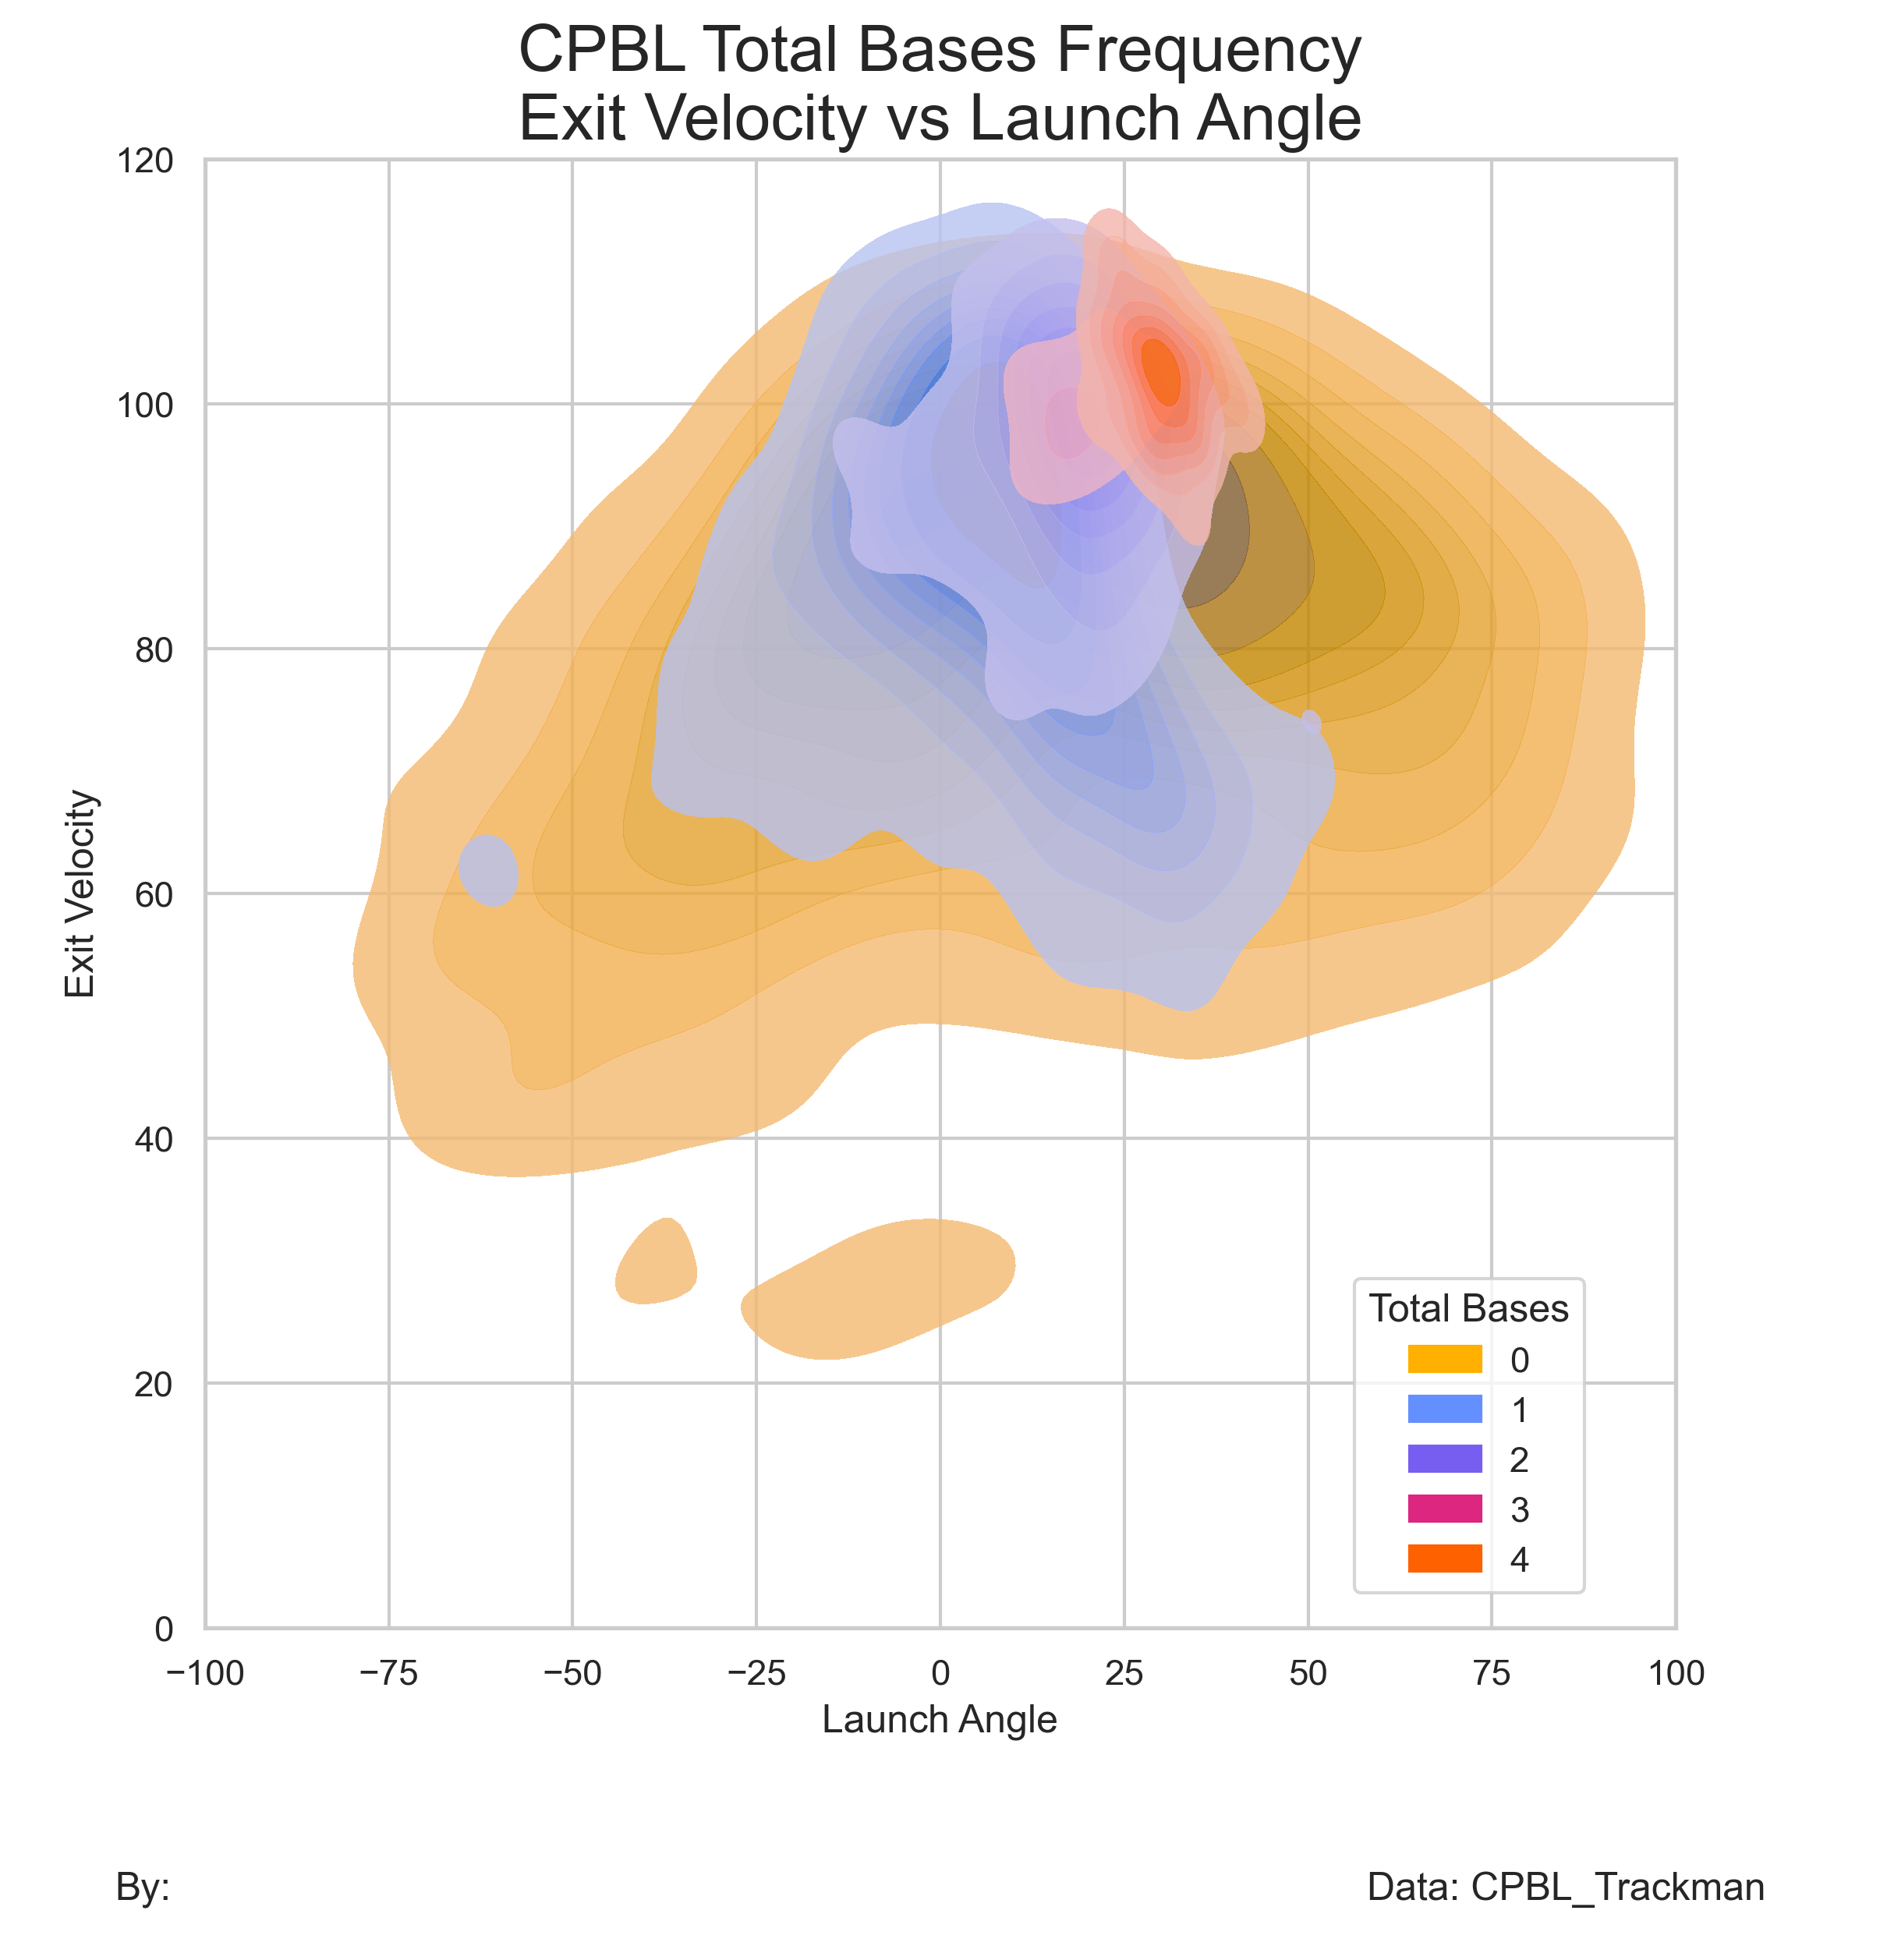

In [29]:
## Initialize plot

sns.set_theme(style="whitegrid", palette=None)
fig = plt.figure(figsize=(8,8),dpi=300)

## Create a grid of subplots to maintain layout
gs = GridSpec(2, 3, height_ratios=[10,1], width_ratios=[0.5,10,0.5])

## Add main subplot and footer subplot
ax = fig.add_subplot(gs[0, 1])
axfooter1 = fig.add_subplot(gs[-1, :])

## Define a custom palette for Total Base outcomes in KDE plot
custom_palette = {0: colour_palette[0], 1: colour_palette[1], 2: colour_palette[2], 3: colour_palette[3], 4: colour_palette[4]}

## Generate KDE plot. Sample 10000 events to avoid extended plotting period
sns.kdeplot(data=data.sample(10000),
             x='Angle',
             y='ExitSpeed',
             hue='tb',ax=ax,
             palette=custom_palette,fill=True,alpha=0.8,legend='Total Bases') 

## Adjust legend and legend title
ax.get_legend().set_title('Total Bases')
ax.get_legend().set_bbox_to_anchor([0.75,0.1,0.2,0.15])

## Add title to plot
ax.set_title('CPBL Total Bases Frequency\nExit Velocity vs Launch Angle',fontsize=20)

## Add axis labels to plot 
ax.set_xlabel('Launch Angle')
ax.set_ylabel('Exit Velocity')

## Adjust x and y-axis bounds
ax.set_ylim(0,120)
ax.set_xlim(-100,100)

## Add footer text 
axfooter1.text(.05, 0.2, "By:",ha='left', va='bottom',fontsize=12)
axfooter1.text(0.95, 0.2, "Data: CPBL_Trackman",ha='right', va='bottom',fontsize=12)
axfooter1.axis('off')


# Adjusting subplot to center it within the figure
fig.subplots_adjust(left=0.01, right=0.99, top=0.975, bottom=0.025)

In [30]:
final_resault = data.copy()

In [31]:
playresult_items = final_resault['result'].unique()
playresult_items

array(['GO', 'FO', '1B', 'FC', 'SO', 'HBP', '2B', 'E', 'GIDP', 'uBB',
       'SH', 'IBB', '3B', 'SF', 'HR', 'D3S', 'ID', 'DP', 'IHR', 'IH',
       'TP'], dtype=object)

In [32]:
#result_to_remove = ['Walk','HitByPitch']
#final_resault= final_resault[~final_resault['PlayResult'].isin(result_to_remove)]

In [33]:
final_resault = final_resault.dropna()

In [34]:
final_resault.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28320 entries, 0 to 92105
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             28320 non-null  object 
 1   bName            28320 non-null  object 
 2   bHand            28320 non-null  object 
 3   bTeamId          28320 non-null  object 
 4   Stadium          28320 non-null  object 
 5   PlayResult       28320 non-null  object 
 6   RunsScored       28320 non-null  float64
 7   traj             28320 non-null  object 
 8   hardness         28320 non-null  object 
 9   ExitSpeed        28320 non-null  float64
 10  Angle            28320 non-null  float64
 11  Distance         28320 non-null  float64
 12  GameID           28320 non-null  object 
 13  TaggedHitType    28320 non-null  object 
 14  KorBB            28320 non-null  object 
 15  BatterId         28320 non-null  float64
 16  PitchCall        28320 non-null  object 
 17  TaggedPitchType  

In [35]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 四.xWOBA 計算

## 特徵篩選

In [36]:
X = final_resault[['ExitSpeed', 'Angle']]
#,'Double','HomeRun','Out','Sacrifice','Single','Triple']]
# 將 y 改為 woba 欄位
y = final_resault[['woba']] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=40)

### KNN (最終使用此模型)

In [37]:
# 2. 建立 Pipeline：先標準化 (StandardScaler) 再跑 KNN
# 對於 2 萬筆數據，嘗試 K=15~30 之間通常效果不錯
model = make_pipeline(
    StandardScaler(), 
    KNeighborsRegressor(n_neighbors=30, weights='distance') # 加入 weights='distance' 讓距離近的樣本權重更高
)

# 3. 訓練模型
model.fit(X_train, y_train)

# 4. 評估
y_pred_test = model.predict(X_test)
print(f"優化後 MSE: {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"優化後 R-squared: {r2_score(y_test, y_pred_test):.4f}")

優化後 MSE: 0.1431
優化後 R-squared: 0.3233


In [38]:
import joblib

# 儲存模型
joblib.dump(model, "woba_model.pkl")
print("模型已儲存！")

模型已儲存！


# 五.整理各球員平均EV,仰角,擊球距離,woba和xwoba

In [39]:
#df_2021 = data[data['Year'] == '2021']
#df_2022 = data[data['Year'] == '2022']
#df_2023 = data[data['Year'] == '2023']
#df_2024 = data[data['Year'] == '2024']
#df1 = pd.concat([df_2021, df_2022], ignore_index=True)
#df2 = pd.concat([df1, df_2023], ignore_index=True)
#df = pd.concat([df2, df_2024], ignore_index=True)
#df_2024 

In [40]:
year_items = data['Year'].unique()
year_items

array(['2026', '2025', '2024', '2023'], dtype=object)

In [41]:
df = data.copy()

In [42]:
# 3. 預測（保留所有原始資料列）
features = ['ExitSpeed', 'Angle']
df['woba_pred'] = np.nan

# 建立遮罩：只針對有資料的列預測
valid_mask = df[features].notna().all(axis=1)

if valid_mask.any():
    # 提取有效數據
    X_predict = df.loc[valid_mask, features]
    
    # 預測直接產出 woba 值，不再需要點積運算與權重陣列
    df.loc[valid_mask, 'woba_pred'] = model.predict(X_predict)

# 檢查結果
print(df[['ExitSpeed', 'Angle', 'woba_pred']].head())

   ExitSpeed      Angle  woba_pred
0   88.43976  -7.061985   0.047436
1   83.98778  38.061691  -0.001306
2   98.03620  19.455446  -0.001306
3   96.86951  15.724575   0.751284
4   46.41542 -50.058005  -0.008229


In [43]:
df

,date,bName,bHand,bTeamId,Stadium,PlayResult,RunsScored,traj,hardness,ExitSpeed,...,時間,日期,Year,bTeam,球場,室內外,球種,tb,woba,woba_pred
0,2026-07-16T10:35:00.000Z,張皓崴,L,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,G,M,88.43976,...,2026-07-16,20260716,2026,Lions,桃園,Outdoor,直球,0,0.047436,0.047436
1,2026-07-16T10:35:00.000Z,陳重羽,R,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,F,M,83.98778,...,2026-07-16,20260716,2026,Lions,桃園,Outdoor,滑球,0,-0.001306,-0.001306
2,2026-07-16T10:35:00.000Z,陳傑憲,L,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,L,H,98.03620,...,2026-07-16,20260716,2026,Lions,桃園,Outdoor,直球,0,-0.001306,-0.001306
3,2026-07-16T10:35:00.000Z,林子偉,L,65630eed5559b6d7a6d5d202,TaoyuanStadium,Single,0.0,L,H,96.86951,...,2026-07-16,20260716,2026,Monkeys,桃園,Outdoor,變速球,1,0.751284,0.751284
4,2026-07-16T10:35:00.000Z,林立,R,65630eed5559b6d7a6d5d202,TaoyuanStadium,FieldersChoice,0.0,G,S,46.41542,...,2026-07-16,20260716,2026,Monkeys,桃園,Outdoor,卡特球,0,-0.008229,-0.008229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92639,2023-10-24T16:00:00.000Z,葉子霆,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,NaN,NaN,NaN,...,2023-10-24,20231024,2023,Guardians,NaN,NaN,曲球,0,0.615195,NaN
92640,2023-10-24T16:00:00.000Z,林岳谷,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,NaN,NaN,NaN,...,2023-10-24,20231024,2023,Guardians,NaN,NaN,直球,0,-0.008252,NaN
92641,2023-10-24T16:00:00.000Z,董子恩,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,G,M,NaN,...,2023-10-24,20231024,2023,Guardians,NaN,NaN,曲球,0,0.047436,NaN
92642,2023-10-24T16:00:00.000Z,王念好,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,L,H,NaN,...,2023-10-24,20231024,2023,Guardians,NaN,NaN,直球,1,0.751284,NaN


In [44]:
playresult_items = df['result'].unique()
playresult_items

array(['GO', 'FO', '1B', 'FC', 'SO', 'HBP', '2B', 'E', 'GIDP', 'uBB',
       'SH', 'IBB', '3B', 'SF', 'HR', 'D3S', 'ID', 'DP', 'IHR', 'IH',
       'TP'], dtype=object)

In [45]:
## Since did not alter the indices, we can assign the predicted xwOBACON to the 2023 dataset 
#df_2023['woba_pred'] = df_bip_2023['woba_pred']

## Assign a value of 0.696 to every walk in the dataset
df.loc[df['result'].isin(['uBB']),'woba_pred'] = 0.603373
df.loc[df['result'].isin(['IBB']),'woba_pred'] = 0.603373

## Assign a value of 0.726 to every hit by pitch in the dataset
df.loc[df['result'].isin(['HBP']),'woba_pred'] = 0.615195

## Assign a value of 0 to every Strikeout in the dataset 
df.loc[df['result'].isin(['D3S','SO']),'woba_pred'] = 0
#df.loc[df['result'].isin(['SF']),'woba'] = 0

## Create a dataframe which is just wOBA events
#df_woba = df.dropna(subset=['woba_pred'])
df_woba = df.copy()

In [46]:
df_woba

,date,bName,bHand,bTeamId,Stadium,PlayResult,RunsScored,traj,hardness,ExitSpeed,...,時間,日期,Year,bTeam,球場,室內外,球種,tb,woba,woba_pred
0,2026-07-16T10:35:00.000Z,張皓崴,L,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,G,M,88.43976,...,2026-07-16,20260716,2026,Lions,桃園,Outdoor,直球,0,0.047436,0.047436
1,2026-07-16T10:35:00.000Z,陳重羽,R,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,F,M,83.98778,...,2026-07-16,20260716,2026,Lions,桃園,Outdoor,滑球,0,-0.001306,-0.001306
2,2026-07-16T10:35:00.000Z,陳傑憲,L,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,L,H,98.03620,...,2026-07-16,20260716,2026,Lions,桃園,Outdoor,直球,0,-0.001306,-0.001306
3,2026-07-16T10:35:00.000Z,林子偉,L,65630eed5559b6d7a6d5d202,TaoyuanStadium,Single,0.0,L,H,96.86951,...,2026-07-16,20260716,2026,Monkeys,桃園,Outdoor,變速球,1,0.751284,0.751284
4,2026-07-16T10:35:00.000Z,林立,R,65630eed5559b6d7a6d5d202,TaoyuanStadium,FieldersChoice,0.0,G,S,46.41542,...,2026-07-16,20260716,2026,Monkeys,桃園,Outdoor,卡特球,0,-0.008229,-0.008229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92639,2023-10-24T16:00:00.000Z,葉子霆,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,NaN,NaN,NaN,...,2023-10-24,20231024,2023,Guardians,NaN,NaN,曲球,0,0.615195,0.615195
92640,2023-10-24T16:00:00.000Z,林岳谷,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,NaN,NaN,NaN,...,2023-10-24,20231024,2023,Guardians,NaN,NaN,直球,0,-0.008252,0.000000
92641,2023-10-24T16:00:00.000Z,董子恩,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,G,M,NaN,...,2023-10-24,20231024,2023,Guardians,NaN,NaN,曲球,0,0.047436,NaN
92642,2023-10-24T16:00:00.000Z,王念好,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,L,H,NaN,...,2023-10-24,20231024,2023,Guardians,NaN,NaN,直球,1,0.751284,NaN


In [47]:
name_mapping = {
    '1B':'1',
    '2B':'1', 
    '3B':'1', 
    'HR':'1',
    'FO':'1',
    'GO':'1',
    'FC':'1',
    'SF':'1',
    'GIDP':'1',
    'E':'1',
    'SH':'1',
    'DP':'1',
    'uBB':'1',
    'IBB':'1',
    'D3S':'1',
    'SO':'1'
    #'Strikeout':'0',
    }

# 新增一列"球員"，根据"Pitcher"列的值匹配中文名
df_woba ['In_Play'] = df_woba ['result'].map(name_mapping)
df_woba['In_Play'] = df_woba['In_Play'].astype(float)
df_woba

,date,bName,bHand,bTeamId,Stadium,PlayResult,RunsScored,traj,hardness,ExitSpeed,...,日期,Year,bTeam,球場,室內外,球種,tb,woba,woba_pred,In_Play
0,2026-07-16T10:35:00.000Z,張皓崴,L,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,G,M,88.43976,...,20260716,2026,Lions,桃園,Outdoor,直球,0,0.047436,0.047436,1.0
1,2026-07-16T10:35:00.000Z,陳重羽,R,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,F,M,83.98778,...,20260716,2026,Lions,桃園,Outdoor,滑球,0,-0.001306,-0.001306,1.0
2,2026-07-16T10:35:00.000Z,陳傑憲,L,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,L,H,98.03620,...,20260716,2026,Lions,桃園,Outdoor,直球,0,-0.001306,-0.001306,1.0
3,2026-07-16T10:35:00.000Z,林子偉,L,65630eed5559b6d7a6d5d202,TaoyuanStadium,Single,0.0,L,H,96.86951,...,20260716,2026,Monkeys,桃園,Outdoor,變速球,1,0.751284,0.751284,1.0
4,2026-07-16T10:35:00.000Z,林立,R,65630eed5559b6d7a6d5d202,TaoyuanStadium,FieldersChoice,0.0,G,S,46.41542,...,20260716,2026,Monkeys,桃園,Outdoor,卡特球,0,-0.008229,-0.008229,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92639,2023-10-24T16:00:00.000Z,葉子霆,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,NaN,NaN,NaN,...,20231024,2023,Guardians,NaN,NaN,曲球,0,0.615195,0.615195,NaN
92640,2023-10-24T16:00:00.000Z,林岳谷,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,NaN,NaN,NaN,...,20231024,2023,Guardians,NaN,NaN,直球,0,-0.008252,0.000000,1.0
92641,2023-10-24T16:00:00.000Z,董子恩,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,G,M,NaN,...,20231024,2023,Guardians,NaN,NaN,曲球,0,0.047436,NaN,1.0
92642,2023-10-24T16:00:00.000Z,王念好,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,L,H,NaN,...,20231024,2023,Guardians,NaN,NaN,直球,1,0.751284,NaN,1.0


In [48]:
name_mapping = {
    '1B':'1',
    '2B':'1', 
    '3B':'1', 
    'HR':'1',
    'FO':'1',
    'GO':'1',
    'FC':'1',
    'GIDP':'1',
    'E':'1',
    'SF':'1',
    'DP':'1',
     }

# 新增一列"球員"，根据"Pitcher"列的值匹配中文名
df_woba ['Hit_In_play'] = df_woba ['result'].map(name_mapping)
df_woba['Hit_In_play'] = df_woba['Hit_In_play'].astype(float)

In [49]:
#player_items = df_woba['Batter'].unique()
#player_items

In [50]:
target_year = ['2023','2024','2025','2026']

fillter_woba = (
    df_woba[
        (df_woba['Year'].isin(target_year)) 
    ]
)

In [51]:
fillter_woba

,date,bName,bHand,bTeamId,Stadium,PlayResult,RunsScored,traj,hardness,ExitSpeed,...,Year,bTeam,球場,室內外,球種,tb,woba,woba_pred,In_Play,Hit_In_play
0,2026-07-16T10:35:00.000Z,張皓崴,L,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,G,M,88.43976,...,2026,Lions,桃園,Outdoor,直球,0,0.047436,0.047436,1.0,1.0
1,2026-07-16T10:35:00.000Z,陳重羽,R,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,F,M,83.98778,...,2026,Lions,桃園,Outdoor,滑球,0,-0.001306,-0.001306,1.0,1.0
2,2026-07-16T10:35:00.000Z,陳傑憲,L,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,L,H,98.03620,...,2026,Lions,桃園,Outdoor,直球,0,-0.001306,-0.001306,1.0,1.0
3,2026-07-16T10:35:00.000Z,林子偉,L,65630eed5559b6d7a6d5d202,TaoyuanStadium,Single,0.0,L,H,96.86951,...,2026,Monkeys,桃園,Outdoor,變速球,1,0.751284,0.751284,1.0,1.0
4,2026-07-16T10:35:00.000Z,林立,R,65630eed5559b6d7a6d5d202,TaoyuanStadium,FieldersChoice,0.0,G,S,46.41542,...,2026,Monkeys,桃園,Outdoor,卡特球,0,-0.008229,-0.008229,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92639,2023-10-24T16:00:00.000Z,葉子霆,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,NaN,NaN,NaN,...,2023,Guardians,NaN,NaN,曲球,0,0.615195,0.615195,NaN,NaN
92640,2023-10-24T16:00:00.000Z,林岳谷,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,NaN,NaN,NaN,...,2023,Guardians,NaN,NaN,直球,0,-0.008252,0.000000,1.0,NaN
92641,2023-10-24T16:00:00.000Z,董子恩,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,G,M,NaN,...,2023,Guardians,NaN,NaN,曲球,0,0.047436,NaN,1.0,1.0
92642,2023-10-24T16:00:00.000Z,王念好,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,L,H,NaN,...,2023,Guardians,NaN,NaN,直球,1,0.751284,NaN,1.0,1.0


In [52]:
import pandas as pd
import numpy as np

# 1. 計算每個 (traj, hardness) 組合的平均 woba_pred
# dropna=False 確保如果 traj 或 hardness 為 NaN 也能被計算到（視需求調整）
woba_means = fillter_woba.groupby(['traj', 'hardness'], dropna=True)['woba_pred'].mean().reset_index()
woba_means = woba_means.rename(columns={'woba_pred': 'woba_pred_mean'})

## 根據 'traj' 和 'hardness' 分組計算平均值，並直接對應回原索引
group_means = fillter_woba.groupby(['traj', 'hardness'])['woba_pred'].transform('mean')

# 僅針對 woba_pred 的空值進行回填，保留原有已存在的值
fillter_woba ['woba_pred'] = fillter_woba ['woba_pred'].fillna(group_means)

In [53]:
woba_means

,traj,hardness,woba_pred_mean
0,F,H,0.563666
1,F,M,0.076920
2,F,S,0.237647
3,G,H,0.380498
4,G,M,0.195589
5,G,S,0.106323
6,L,H,0.594231
7,L,M,0.473055
8,L,S,0.371674
9,P,H,0.000600


In [54]:
fillter_woba

,date,bName,bHand,bTeamId,Stadium,PlayResult,RunsScored,traj,hardness,ExitSpeed,...,Year,bTeam,球場,室內外,球種,tb,woba,woba_pred,In_Play,Hit_In_play
0,2026-07-16T10:35:00.000Z,張皓崴,L,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,G,M,88.43976,...,2026,Lions,桃園,Outdoor,直球,0,0.047436,0.047436,1.0,1.0
1,2026-07-16T10:35:00.000Z,陳重羽,R,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,F,M,83.98778,...,2026,Lions,桃園,Outdoor,滑球,0,-0.001306,-0.001306,1.0,1.0
2,2026-07-16T10:35:00.000Z,陳傑憲,L,65630ef25559b6d7a6d5d203,TaoyuanStadium,Out,0.0,L,H,98.03620,...,2026,Lions,桃園,Outdoor,直球,0,-0.001306,-0.001306,1.0,1.0
3,2026-07-16T10:35:00.000Z,林子偉,L,65630eed5559b6d7a6d5d202,TaoyuanStadium,Single,0.0,L,H,96.86951,...,2026,Monkeys,桃園,Outdoor,變速球,1,0.751284,0.751284,1.0,1.0
4,2026-07-16T10:35:00.000Z,林立,R,65630eed5559b6d7a6d5d202,TaoyuanStadium,FieldersChoice,0.0,G,S,46.41542,...,2026,Monkeys,桃園,Outdoor,卡特球,0,-0.008229,-0.008229,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92639,2023-10-24T16:00:00.000Z,葉子霆,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,NaN,NaN,NaN,...,2023,Guardians,NaN,NaN,曲球,0,0.615195,0.615195,NaN,NaN
92640,2023-10-24T16:00:00.000Z,林岳谷,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,NaN,NaN,NaN,...,2023,Guardians,NaN,NaN,直球,0,-0.008252,0.000000,1.0,NaN
92641,2023-10-24T16:00:00.000Z,董子恩,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,G,M,NaN,...,2023,Guardians,NaN,NaN,曲球,0,0.047436,0.195589,1.0,1.0
92642,2023-10-24T16:00:00.000Z,王念好,R,65630ef65559b6d7a6d5d204,NaN,NaN,NaN,L,H,NaN,...,2023,Guardians,NaN,NaN,直球,1,0.751284,0.594231,1.0,1.0


In [55]:
fillter_woba.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92644 entries, 0 to 92643
Data columns (total 33 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             92644 non-null  object 
 1   bName            92644 non-null  object 
 2   bHand            92644 non-null  object 
 3   bTeamId          92644 non-null  object 
 4   Stadium          43047 non-null  object 
 5   PlayResult       43050 non-null  object 
 6   RunsScored       43049 non-null  float64
 7   traj             68603 non-null  object 
 8   hardness         67117 non-null  object 
 9   ExitSpeed        29982 non-null  float64
 10  Angle            29982 non-null  float64
 11  Distance         28618 non-null  float64
 12  GameID           43047 non-null  object 
 13  TaggedHitType    43050 non-null  object 
 14  KorBB            43050 non-null  object 
 15  BatterId         43064 non-null  float64
 16  PitchCall        43050 non-null  object 
 17  TaggedPitchT

## 計算單人平均

In [56]:
# 1. 定義分子要加總的項目 (wOBA weights)
numerator_results = ['uBB', 'HBP', '1B', '2B', '3B', 'HR']
Woba_scale = 1.2269079390079072

# 2. 定義不計入分母的項目 (通常 wOBA 會排除 IBB)
# 如果你的 PA 本身就不含 IBB，這步可省略
#exclude_from_pa = ['IBB']

# 3. 處理數據
# 只有在 numerator_results 裡的才保留權重，其餘（如 SO, FO, GO）權重設為 0
fillter_woba['woba_value'] = np.where(
    fillter_woba['result'].isin(numerator_results), 
    fillter_woba['woba'], 
    0
)

# 4. 進行分組計算
df_output = fillter_woba.groupby(['bName','bTeam', 'Year']).apply(lambda x: pd.Series({
    'woba_pa': x['In_Play'].sum(),
    'woba': (x['woba_value'].sum() * Woba_scale / x['In_Play'].sum()) if x['In_Play'].sum() > 0 else 0,
    'xwoba': x['woba_pred'].mean() * Woba_scale
})).reset_index()

df_output2 = fillter_woba[fillter_woba['Hit_In_play'] == 1].groupby(['bName','bTeam','Year']).agg(
    EV = ('ExitSpeed','mean'),
    Angle = ('Angle','mean'),
    Distance = ('Distance','mean')
).reset_index()

merged_df = df_output.merge(df_output2, on=['bName','bTeam','Year'])
merged_df['EV(KM)'] = merged_df['EV']*1.609
merged_df['woba_diff']=merged_df['xwoba']-merged_df['woba']
merged_df.reset_index(drop=False, inplace=True)
merged_df

C:\Users\weisz\AppData\Local\Temp\ipykernel_14036\2575646611.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_output = fillter_woba.groupby(['bName','bTeam', 'Year']).apply(lambda x: pd.Series({


,index,bName,bTeam,Year,woba_pa,woba,xwoba,EV,Angle,Distance,EV(KM),woba_diff
0,0,于森旭,Guardians,2023,38.0,0.156712,0.172541,NaN,NaN,NaN,NaN,0.015829
1,1,何品室融,Monkeys,2025,10.0,0.166204,0.183756,80.255098,27.744453,99.725227,129.130452,0.017552
2,2,何品室融,Monkeys,2026,137.0,0.276982,0.296081,84.100715,4.101933,156.322112,135.318051,0.019100
3,3,何恆佑,Lions,2023,47.0,0.190709,0.205675,87.299487,13.740787,165.293991,140.464874,0.014966
4,4,何恆佑,Lions,2024,70.0,0.217917,0.227442,86.713812,12.735039,223.453606,139.522524,0.009525
...,...,...,...,...,...,...,...,...,...,...,...,...
651,651,黃鈞麟,Brothers,2024,4.0,0.000000,0.181933,NaN,NaN,NaN,NaN,0.181933
652,652,黃鈞麟,Brothers,2025,4.0,0.185071,0.325998,72.152875,-16.974378,90.050105,116.093976,0.140928
653,653,黃韋盛,Brothers,2023,92.0,0.237851,0.200009,85.754221,1.104612,120.361033,137.978542,-0.037842
654,654,黃韋盛,Brothers,2025,341.0,0.311012,0.295126,85.004540,3.409069,134.488400,136.772305,-0.015886


#### 匯出檔案

In [57]:
merged_df.to_excel('2026_Player_xWOBA.xlsx', index=True)

## 計算團隊平均

In [58]:
# 1. 定義分子要加總的項目 (wOBA weights)
numerator_results = ['uBB', 'HBP', '1B', '2B', '3B', 'HR']
#Woba_scale = 1.2269079390079072

# 2. 定義不計入分母的項目 (通常 wOBA 會排除 IBB)
# 如果你的 PA 本身就不含 IBB，這步可省略
#exclude_from_pa = ['IBB']

# 3. 處理數據
# 只有在 numerator_results 裡的才保留權重，其餘（如 SO, FO, GO）權重設為 0
fillter_woba['woba_value'] = np.where(
    fillter_woba['result'].isin(numerator_results), 
    fillter_woba['woba'], 
    0
)

# 4. 進行分組計算
df_output = fillter_woba.groupby(['bTeam', 'Year']).apply(lambda x: pd.Series({
    'woba_pa': x['In_Play'].sum(),
    'woba': x['woba_value'].sum()*Woba_scale / x['In_Play'].sum() if x['In_Play'].sum() > 0 else 0,
    'xwoba': x['woba_pred'].mean()*Woba_scale
})).reset_index()

df_output2 = fillter_woba[fillter_woba['Hit_In_play'] == 1].groupby(['bTeam','Year']).agg(
    EV = ('ExitSpeed','mean'),
    Angle = ('Angle','mean'),
    Distance = ('Distance','mean')
).reset_index()

merged_df = df_output.merge(df_output2, on=['bTeam','Year'])
merged_df['EV(KM)'] = merged_df['EV']*1.609
merged_df['woba_diff']=merged_df['xwoba']-merged_df['woba']
merged_df.reset_index(drop=False, inplace=True)
merged_df

C:\Users\weisz\AppData\Local\Temp\ipykernel_14036\2507156474.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_output = fillter_woba.groupby(['bTeam', 'Year']).apply(lambda x: pd.Series({


,index,bTeam,Year,woba_pa,woba,xwoba,EV,Angle,Distance,EV(KM),woba_diff
0,0,Brothers,2023,4578.0,0.313586,0.289169,83.237987,10.958809,161.006690,133.929921,-0.024417
1,1,Brothers,2024,4593.0,0.332448,0.331760,87.000364,16.750267,189.762331,139.983586,-0.000688
2,2,Brothers,2025,4497.0,0.318395,0.317748,85.621317,10.468085,159.225104,137.764698,-0.000647
3,3,Brothers,2026,2504.0,0.310462,0.319979,86.088681,11.643826,159.653034,138.516688,0.009517
4,4,Dragons,2023,4388.0,0.314852,0.290391,82.470842,11.163349,156.487171,132.695585,-0.024462
5,5,Dragons,2024,4418.0,0.310789,0.289082,84.646237,14.679954,177.721213,136.195795,-0.021708
6,6,Dragons,2025,4462.0,0.322207,0.321258,84.650561,11.540747,160.211162,136.202753,-0.000949
7,7,Dragons,2026,2552.0,0.315707,0.318870,85.502373,12.540925,156.791893,137.573319,0.003163
8,8,Guardians,2023,4526.0,0.309594,0.274702,82.135252,14.881810,166.889918,132.155620,-0.034893
9,9,Guardians,2024,4480.0,0.311093,0.283690,84.704016,13.453489,168.801702,136.288762,-0.027404


In [59]:
#merged_df.to_excel('2026_Team_xWOBA.xlsx', index=True)

In [64]:
start_date = 20260701
end_date = 20260716

# 篩選日期 20260428 ~ 20260503
fillter_woba['日期_int'] = fillter_woba['日期'].astype(int)
fillter_woba2 = fillter_woba[
    (fillter_woba['日期_int'] >= start_date) & 
    (fillter_woba['日期_int'] <= end_date)  
    #(fillter_woba['bTeam'] == '兄弟')
]

# 1. 定義分子要加總的項目
numerator_results = ['uBB', 'HBP', '1B', '2B', '3B', 'HR']
#Woba_scale = 1.2269079390079072

# 3. 處理數據
fillter_woba2['woba_value'] = np.where(
    fillter_woba2['result'].isin(numerator_results),
    fillter_woba2['woba'],
    0
)

# 4. 進行分組計算
df_output = fillter_woba2.groupby(['bName','bTeam', 'Year']).apply(lambda x: pd.Series({
    'woba_pa': x['In_Play'].sum(),
    'woba': (x['woba_value'].sum() * Woba_scale / x['In_Play'].sum()) if x['In_Play'].sum() > 0 else 0,
    'xwoba': x['woba_pred'].mean() * Woba_scale
})).reset_index()

# 修改 df_output2 的邏輯，避免 In_Play 變成索引的一部分導致 merge 困難
# 這裡過濾 In_Play == 1 的擊球數據來計算平均值
df_output2 = fillter_woba2[fillter_woba2['Hit_In_play'] == 1].groupby(['bName','bTeam','Year']).agg(
    EV = ('ExitSpeed','mean'),
    Angle = ('Angle','mean'),
    Distance = ('Distance','mean')
).reset_index()

# 合併數據
merged_df = df_output.merge(df_output2, on=['bName','bTeam','Year'], how='left')
merged_df['EV(KM)'] = merged_df['EV'] * 1.609
merged_df['woba_diff'] = merged_df['xwoba'] - merged_df['woba']

# 格式化輸出
merged_df = merged_df.round(3)
merged_df.rename(columns={
    'bName': 'bName',
    'bTeam': 'bTeam',
    'Year': 'Year',
    'woba_pa': 'PA',
    'EV': 'AVG_EV',
    'Angle': 'AVG_LA',
    'Distance': 'AVG_Distance'
}, inplace=True)

# 儲存 Excel
merged_df

C:\Users\weisz\AppData\Local\Temp\ipykernel_14036\2617631621.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fillter_woba2['woba_value'] = np.where(
C:\Users\weisz\AppData\Local\Temp\ipykernel_14036\2617631621.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_output = fillter_woba2.groupby(['bName','bTeam', 'Year']).apply(lambda x: pd.Series({


,bName,bTeam,Year,PA,woba,xwoba,AVG_EV,AVG_LA,AVG_Distance,EV(KM),woba_diff
0,何品室融,Monkeys,2026,11.0,0.287,0.282,75.788,-9.938,63.319,121.942,-0.005
1,何恆佑,Lions,2026,2.0,0.000,0.065,NaN,NaN,NaN,NaN,0.065
2,余羿賢,Lions,2026,1.0,0.000,0.000,NaN,NaN,NaN,NaN,0.000
3,劉俊緯,Dragons,2026,24.0,0.341,0.390,84.730,16.911,203.069,136.330,0.049
4,劉俊豪,Guardians,2026,6.0,0.277,0.188,85.884,14.952,136.574,138.188,-0.089
...,...,...,...,...,...,...,...,...,...,...,...
101,高宇杰,Brothers,2026,24.0,0.356,0.343,86.380,20.417,178.542,138.985,-0.013
102,高聖恩,Hawks,2026,11.0,0.236,0.260,81.496,12.676,178.422,131.127,0.024
103,魔鷹,Hawks,2026,32.0,0.246,0.282,98.893,15.747,154.411,159.118,0.036
104,黃劼希,Hawks,2026,8.0,0.208,0.215,78.415,-14.328,118.339,126.169,0.007


In [65]:
# 修改儲存檔名，加入日期區間
file_name = f'Player_xWOBA_{start_date}_{end_date}.xlsx'

# 儲存 Excel
merged_df.to_excel(file_name, index=True)

In [66]:
# 1. 定義分子要加總的項目
numerator_results = ['uBB', 'HBP', '1B', '2B', '3B', 'HR']

# 1. 定義目標區域
target_zones = [7, 8, 9, 12, 13, 14, 17, 18, 19]

# 2. 篩選指定 zone25 的數據 (直接在計算前過濾)
fillter_woba_zone = fillter_woba2[fillter_woba2['zone25'].isin(target_zones)].copy()

# 3. 處理數據 (使用過濾後的 fillter_woba_zone)
fillter_woba_zone['woba_value'] = np.where(
    fillter_woba_zone['result'].isin(numerator_results),
    fillter_woba_zone['woba'],
    0
)

# 4. 進行分組計算 (woba 部分)
df_output = fillter_woba_zone.groupby(['bName','bTeam', 'Year']).apply(lambda x: pd.Series({
    'woba_pa': x['In_Play'].sum(),
    'woba': (x['woba_value'].sum() * Woba_scale / x['In_Play'].sum()) if x['In_Play'].sum() > 0 else 0,
    'xwoba': x['woba_pred'].mean() * Woba_scale
})).reset_index()

# 5. 處理擊球數據 (同樣使用過濾後的 fillter_woba_zone)
df_output2 = fillter_woba_zone[fillter_woba_zone['Hit_In_play'] == 1].groupby(['bName','bTeam','Year']).agg(
    EV = ('ExitSpeed','mean'),
    Angle = ('Angle','mean'),
    Distance = ('Distance','mean')
).reset_index()

# 6. 合併與後續處理
merged_df = df_output.merge(df_output2, on=['bName','bTeam','Year'], how='left')
merged_df['EV(KM)'] = merged_df['EV'] * 1.609
merged_df['woba_diff'] = merged_df['xwoba'] - merged_df['woba']

# 7. 格式化輸出
merged_df = merged_df.round(3)
merged_df.rename(columns={
    'woba_pa': 'PA',
    'EV': 'AVG_EV',
    'Angle': 'AVG_LA',
    'Distance': 'AVG_Distance'
}, inplace=True)

# 儲存 Excel
merged_df

C:\Users\weisz\AppData\Local\Temp\ipykernel_14036\991921925.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_output = fillter_woba_zone.groupby(['bName','bTeam', 'Year']).apply(lambda x: pd.Series({


,bName,bTeam,Year,PA,woba,xwoba,AVG_EV,AVG_LA,AVG_Distance,EV(KM),woba_diff
0,何品室融,Monkeys,2026,5.0,0.184,0.219,79.829,-4.874,89.790,128.445,0.035
1,何恆佑,Lions,2026,2.0,0.000,0.065,NaN,NaN,NaN,NaN,0.065
2,劉俊緯,Dragons,2026,15.0,0.397,0.439,87.296,15.418,209.546,140.458,0.042
3,劉俊豪,Guardians,2026,2.0,0.461,0.462,85.813,19.584,8.060,138.074,0.001
4,劉基鴻,Dragons,2026,23.0,0.240,0.256,88.229,31.464,179.201,141.960,0.015
...,...,...,...,...,...,...,...,...,...,...,...
96,高宇杰,Brothers,2026,17.0,0.296,0.313,86.071,20.437,156.526,138.487,0.017
97,高聖恩,Hawks,2026,9.0,0.205,0.249,81.496,12.676,178.422,131.127,0.044
98,魔鷹,Hawks,2026,12.0,0.333,0.445,101.125,25.668,187.745,162.711,0.112
99,黃劼希,Hawks,2026,2.0,0.461,0.490,77.116,-31.721,58.902,124.080,0.029


In [67]:
# 修改儲存檔名，加入日期區間
file_name = f'Player_xWOBA_inZone_{start_date}_{end_date}.xlsx'

# 儲存 Excel
merged_df.to_excel(file_name, index=True)